# Facial Expression Recognition — RAF-DB (Balanced)
## 6G7V0024 Deep Learning Coursework

**Dataset:** Real-world Affective Faces Database (RAF-DB) — balanced version built from scratch.  
**Reference:** S. Li and W. Deng, *Reliable Crowdsourcing and Deep Locality-Preserving Learning for Expression Recognition in the Wild*, CVPR 2017.

## Pipeline
```
Original RAF-DB (imbalanced, colour)
  ↓  Section 1 — Data Preparation
Balanced RAF-DB (grayscale 75x75, 8988/class, augmented)
  ↓  Section 2 — Modelling
Model A: Custom CNN             (baseline)
Model B: ResNet-50 pretrained   (transfer learning)
Model C: ResNet-50 + CBAM       (our modification)
Model D: ResNet-50 + CBAM + FL  (full method)
  ↓  Section 3 — Analysis
Ablation, Grad-CAM, Qualitative, Gradio app
```

> **Checkpoint reuse:** `train_model()` saves best weights. Re-running loads them instantly.

In [1]:
# CELL 1 — Installs
!pip install torchmetrics torchinfo gradio -q

In [2]:
# CELL 2 — Imports & reproducibility
import os, random, warnings
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageEnhance
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms.v2 as v2
from torchvision.models import resnet50, ResNet50_Weights
import torchmetrics
from torchinfo import summary

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
# CELL 3 — Constants & paths

# Original RAF-DB folder mapping: 1=Surprise 2=Fear 3=Disgust
# 4=Happiness 5=Sadness 6=Anger 7=Neutral
ORIG_LABEL_MAP = {
    '1': 'Surprise', '2': 'Fear', '3': 'Disgust',
    '4': 'Happy',    '5': 'Sad',  '6': 'Angry',  '7': 'Neutral'
}

# Balanced dataset specs (matching Balanced RAF-DB description)
IMG_SIZE         = 75
TARGET_PER_CLASS = 8988
TRAIN_RATIO      = 0.80
VAL_RATIO        = 0.10
TEST_RATIO       = 0.10

# Model hyperparameters
BATCH_SIZE = 64
NUM_EPOCHS = 25
LR         = 1e-4
NUM_CLASSES = 7

# Auto-detect original RAF-DB mount path
POSSIBLE_ROOTS = [
    '/kaggle/input/raf-db-dataset',
    '/kaggle/input/datasets/shuvoalok/raf-db-dataset',
]
ORIG_ROOT = next(
    (p for p in POSSIBLE_ROOTS
     if os.path.exists(os.path.join(p, 'DATASET', 'train'))), None
)
if ORIG_ROOT is None:
    for root, dirs, _ in os.walk('/kaggle/input'):
        if 'train' in dirs and 'test' in dirs:
            ORIG_ROOT = os.path.dirname(root); break
assert ORIG_ROOT, 'Original RAF-DB not found — check Kaggle dataset mount'

ORIG_TRAIN = os.path.join(ORIG_ROOT, 'DATASET', 'train')
ORIG_TEST  = os.path.join(ORIG_ROOT, 'DATASET', 'test')
BAL_ROOT   = '/kaggle/working/balanced_rafdb'
CKPT_DIR   = '/kaggle/working/checkpoints'
OUT_DIR    = '/kaggle/working'
for d in [BAL_ROOT, CKPT_DIR]: os.makedirs(d, exist_ok=True)

print(f'Original RAF-DB : {ORIG_ROOT}')
print(f'Balanced output : {BAL_ROOT}')
print(f'Target/class    : {TARGET_PER_CLASS:,}  |  Total: {TARGET_PER_CLASS*NUM_CLASSES:,}')

Original RAF-DB : /kaggle/input/datasets/shuvoalok/raf-db-dataset
Balanced output : /kaggle/working/balanced_rafdb
Target/class    : 8,988  |  Total: 62,916


---
## Section 1 — Building the Balanced Dataset

We replicate the Balanced RAF-DB preprocessing pipeline:
1. Collect all images from original train + test splits combined
2. Convert to **grayscale**, resize to **75×75**
3. For minority classes (Fear, Disgust, Anger, Surprise): **augment** to reach 8,988
4. For majority class (Happiness): **randomly sample down** to 8,988
5. Split **80% train / 10% val / 10% test** per class
6. Save in `ImageFolder` structure

In [4]:
# CELL 4 — Count original images per class

def collect_all_images(orig_train, orig_test, label_map):
    class_images = {cls: [] for cls in label_map.values()}
    for split_dir in [orig_train, orig_test]:
        for folder_num, class_name in label_map.items():
            folder = os.path.join(split_dir, folder_num)
            if not os.path.exists(folder): continue
            for fname in os.listdir(folder):
                if fname.lower().endswith(('.jpg','.jpeg','.png')):
                    class_images[class_name].append(os.path.join(folder, fname))
    return class_images

class_images = collect_all_images(ORIG_TRAIN, ORIG_TEST, ORIG_LABEL_MAP)

print(f'{"Class":<12} {"Original":>9}  {"Need":>8}  Action')
print('─' * 45)
for cls, paths in class_images.items():
    need = TARGET_PER_CLASS - len(paths)
    action = f'augment +{need:,}' if need > 0 else f'downsample {-need:,}'
    print(f'{cls:<12} {len(paths):>9}  {abs(need):>8}  {action}')
print('─' * 45)
print(f'Target per class: {TARGET_PER_CLASS:,}')

Class         Original      Need  Action
─────────────────────────────────────────────
Surprise          1619      7369  augment +7,369
Fear               355      8633  augment +8,633
Disgust            877      8111  augment +8,111
Happy             5957      3031  augment +3,031
Sad               2460      6528  augment +6,528
Angry              867      8121  augment +8,121
Neutral           3204      5784  augment +5,784
─────────────────────────────────────────────
Target per class: 8,988


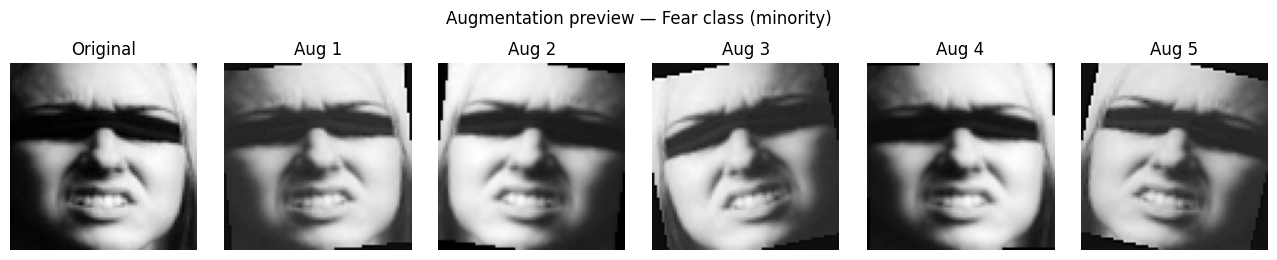

In [5]:
# CELL 5 — Augmentation functions

def preprocess(path):
    """Load → grayscale → 75x75."""
    return Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)

def augment(img, rng):
    """
    Random augmentation matching the Balanced RAF-DB pipeline:
    rotation, horizontal flip, brightness, contrast, sharpness.
    """
    img = img.rotate(rng.uniform(-20, 20), resample=Image.BILINEAR)
    if rng.random() > 0.5: img = img.transpose(Image.FLIP_LEFT_RIGHT)
    img = ImageEnhance.Brightness(img).enhance(rng.uniform(0.7, 1.3))
    img = ImageEnhance.Contrast(img).enhance(rng.uniform(0.8, 1.2))
    img = ImageEnhance.Sharpness(img).enhance(rng.uniform(0.8, 1.5))
    return img

# Preview augmentation
rng = random.Random(SEED)
sample = preprocess(class_images['Fear'][0])
fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))
axes[0].imshow(sample, cmap='gray'); axes[0].set_title('Original')
for i in range(1, 6):
    axes[i].imshow(augment(sample, rng), cmap='gray')
    axes[i].set_title(f'Aug {i}')
for ax in axes: ax.axis('off')
plt.suptitle('Augmentation preview — Fear class (minority)', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/augmentation_preview.png', dpi=150, bbox_inches='tight'); plt.show()

In [6]:
# CELL 6 — Build balanced dataset on disk

def build_balanced_dataset(class_images, target, out_root,
                            train_r, val_r, test_r, seed=42):
    rng = random.Random(seed)
    for split in ['train','val','test']:
        for cls in class_images: os.makedirs(os.path.join(out_root,split,cls), exist_ok=True)

    for cls, paths in class_images.items():
        print(f'\n{cls}: {len(paths)} original → {target} target')

        # Preprocess all originals
        processed = []
        for p in tqdm(paths, desc=f'  Preprocess', leave=False):
            try: processed.append(preprocess(p))
            except: pass

        # Reach target via augmentation or downsampling
        images = list(processed)
        if len(images) < target:
            needed = target - len(images)
            for _ in tqdm(range(needed), desc=f'  Augment', leave=False):
                images.append(augment(rng.choice(processed), rng))
        else:
            rng.shuffle(images)
            images = images[:target]

        # Shuffle and split
        rng.shuffle(images)
        n = len(images)
        n_tr  = int(n * train_r)
        n_val = int(n * val_r)
        splits = {'train': images[:n_tr],
                  'val':   images[n_tr:n_tr+n_val],
                  'test':  images[n_tr+n_val:]}

        # Save
        for split, imgs in splits.items():
            out = os.path.join(out_root, split, cls)
            for idx, img in enumerate(tqdm(imgs, desc=f'  Save {split}', leave=False)):
                img.save(os.path.join(out, f'{cls}_{split}_{idx:05d}.png'))
        print(f'  done → train={len(splits["train"])} val={len(splits["val"])} test={len(splits["test"])}')


# Only build if not already done
check = os.path.join(BAL_ROOT,'train',list(ORIG_LABEL_MAP.values())[0])
if os.path.exists(check) and len(os.listdir(check)) > 100:
    print(f'Balanced dataset already exists — skipping build.')
    print(f'Delete {BAL_ROOT} to rebuild from scratch.')
else:
    print('Building balanced dataset (~5-10 min)...')
    build_balanced_dataset(class_images, TARGET_PER_CLASS, BAL_ROOT,
                           TRAIN_RATIO, VAL_RATIO, TEST_RATIO, SEED)
    print('\nBalanced dataset built successfully ✓')

Building balanced dataset (~5-10 min)...

Surprise: 1619 original → 8988 target


  Preprocess:   0%|          | 0/1619 [00:00<?, ?it/s]

  Augment:   0%|          | 0/7369 [00:00<?, ?it/s]

  Save train:   0%|          | 0/7190 [00:00<?, ?it/s]

  Save val:   0%|          | 0/898 [00:00<?, ?it/s]

...

  Augment:   0%|          | 0/5784 [00:00<?, ?it/s]

  Save train:   0%|          | 0/7190 [00:00<?, ?it/s]

  Save val:   0%|          | 0/898 [00:00<?, ?it/s]

  Save test:   0%|          | 0/900 [00:00<?, ?it/s]

  done → train=7190 val=898 test=900

Balanced dataset built successfully ✓


Class           Train      Val     Test    Total
────────────────────────────────────────────────
Angry            7190      898      900     8988
Disgust          7190      898      900     8988
Fear             7190      898      900     8988
Happy            7190      898      900     8988
Neutral          7190      898      900     8988
Sad              7190      898      900     8988
Surprise         7190      898      900     8988
────────────────────────────────────────────────
TOTAL           50330     6286     6300    62916


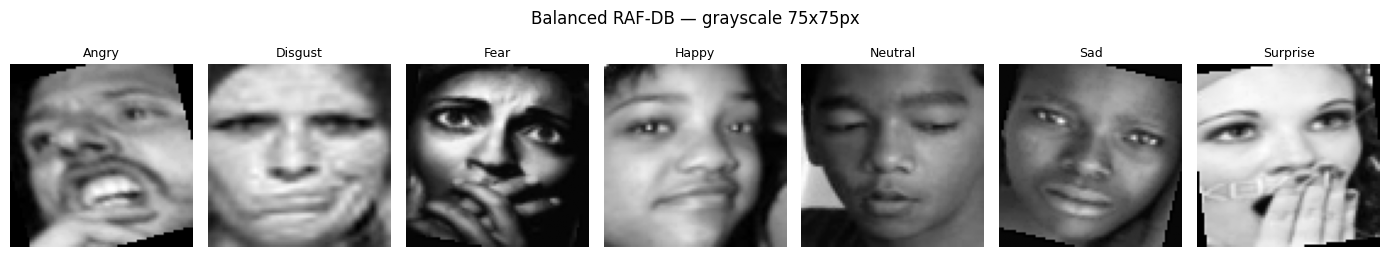

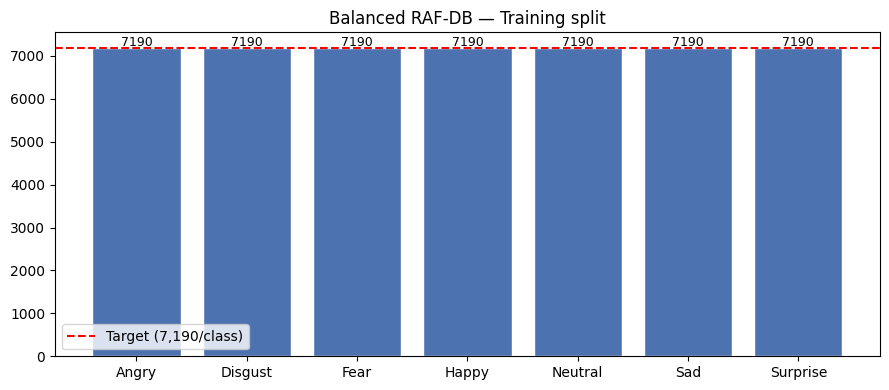

Dataset perfectly balanced ✓


In [7]:
# CELL 7 — Verify balanced dataset

classes_sorted = sorted(os.listdir(os.path.join(BAL_ROOT,'train')))
CLASSES = classes_sorted  # update global CLASSES to ImageFolder order

print(f'{"Class":<12} {"Train":>8} {"Val":>8} {"Test":>8} {"Total":>8}')
print('─'*48)
totals = {'train':0,'val':0,'test':0}
for cls in CLASSES:
    c = {s: len(os.listdir(os.path.join(BAL_ROOT,s,cls)))
         if os.path.exists(os.path.join(BAL_ROOT,s,cls)) else 0
         for s in ['train','val','test']}
    for s in c: totals[s] += c[s]
    print(f'{cls:<12} {c["train"]:>8} {c["val"]:>8} {c["test"]:>8} {sum(c.values()):>8}')
print('─'*48)
print(f'{"TOTAL":<12} {totals["train"]:>8} {totals["val"]:>8} {totals["test"]:>8} {sum(totals.values()):>8}')

# Sample images
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(14, 2.5))
for i, cls in enumerate(CLASSES):
    d = os.path.join(BAL_ROOT,'train',cls)
    axes[i].imshow(Image.open(os.path.join(d,os.listdir(d)[0])), cmap='gray')
    axes[i].set_title(cls, fontsize=9); axes[i].axis('off')
plt.suptitle(f'Balanced RAF-DB — grayscale {IMG_SIZE}x{IMG_SIZE}px', y=1.02)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/balanced_samples.png', dpi=150, bbox_inches='tight'); plt.show()

# Distribution bar chart
fig, ax = plt.subplots(figsize=(9,4))
tr_counts = [len(os.listdir(os.path.join(BAL_ROOT,'train',c))) for c in CLASSES]
ax.bar(CLASSES, tr_counts, color='#4C72B0', edgecolor='white')
ax.axhline(int(TARGET_PER_CLASS*TRAIN_RATIO), ls='--', color='red',
           label=f'Target ({int(TARGET_PER_CLASS*TRAIN_RATIO):,}/class)')
ax.set_title('Balanced RAF-DB — Training split'); ax.legend()
for i, v in enumerate(tr_counts): ax.text(i, v+30, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/balanced_distribution.png', dpi=150); plt.show()
print('Dataset perfectly balanced ✓')

---
## Section 2 — Model Training

In [8]:
# CELL 8 — Transforms & DataLoaders

# 3-channel transform (grayscale repeated 3x) for pretrained ResNet
train_tf3 = v2.Compose([
    v2.Grayscale(num_output_channels=3),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomRotation(10),
    v2.ColorJitter(brightness=0.2, contrast=0.2),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])
eval_tf3 = v2.Compose([
    v2.Grayscale(num_output_channels=3),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5]),
])

# 1-channel transform for Custom CNN
train_tf1 = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.RandomHorizontalFlip(0.5),
    v2.RandomRotation(10),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5],[0.5]),
])
eval_tf1 = v2.Compose([
    v2.Grayscale(num_output_channels=1),
    v2.ToImage(), v2.ToDtype(torch.float32, scale=True),
    v2.Normalize([0.5],[0.5]),
])

def make_loaders(train_tf, eval_tf, bs=BATCH_SIZE):
    tr = torchvision.datasets.ImageFolder(os.path.join(BAL_ROOT,'train'), transform=train_tf)
    vl = torchvision.datasets.ImageFolder(os.path.join(BAL_ROOT,'val'),   transform=eval_tf)
    te = torchvision.datasets.ImageFolder(os.path.join(BAL_ROOT,'test'),  transform=eval_tf)
    return (DataLoader(tr, bs, shuffle=True,  num_workers=2, pin_memory=True),
            DataLoader(vl, bs, shuffle=False, num_workers=2, pin_memory=True),
            DataLoader(te, bs, shuffle=False, num_workers=2, pin_memory=True),
            tr.classes)

train_loader3, val_loader3, test_loader3, CLASSES = make_loaders(train_tf3, eval_tf3)
train_loader1, val_loader1, test_loader1, _       = make_loaders(train_tf1, eval_tf1)

print(f'Classes (sorted): {CLASSES}')
print(f'3-ch loaders — Train:{len(train_loader3.dataset):,} Val:{len(val_loader3.dataset):,} Test:{len(test_loader3.dataset):,}')
print(f'Batches per epoch: {len(train_loader3)}')

Classes (sorted): ['Angry', 'Disgust', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']
3-ch loaders — Train:50,330 Val:6,286 Test:6,300
Batches per epoch: 787


In [9]:
# CELL 9 — Model definitions

class CustomCNN(nn.Module):
    """
    Model A — Custom CNN trained from scratch.
    Input: (B, 1, 75, 75) — single-channel grayscale.
    4 conv blocks + GAP + 3-layer FC classifier.
    This is the true baseline — no pretrained weights.
    With balanced data it should reach ~70-80%.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(True),
            nn.Conv2d(32,32,3,padding=1),nn.BatchNorm2d(32),nn.ReLU(True),
            nn.MaxPool2d(2),nn.Dropout2d(0.1),

            nn.Conv2d(32,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(True),
            nn.Conv2d(64,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(True),
            nn.MaxPool2d(2),nn.Dropout2d(0.1),

            nn.Conv2d(64,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(True),
            nn.Conv2d(128,128,3,padding=1),nn.BatchNorm2d(128),nn.ReLU(True),
            nn.MaxPool2d(2),nn.Dropout2d(0.2),

            nn.Conv2d(128,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(True),
            nn.Conv2d(256,256,3,padding=1),nn.BatchNorm2d(256),nn.ReLU(True),
            nn.MaxPool2d(2),nn.Dropout2d(0.2),
        )
        self.gap = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(256,256),nn.ReLU(True),nn.Dropout(0.5),
            nn.Linear(256,128),nn.ReLU(True),nn.Dropout(0.3),
            nn.Linear(128,num_classes),
        )
    def forward(self, x):
        return self.classifier(self.gap(self.features(x)).flatten(1))


class ResNet50_Transfer(nn.Module):
    """
    Model B — ImageNet pretrained ResNet-50, FC replaced with 7-class head.
    All layers fine-tuned. Input: (B, 3, 75, 75) — grayscale repeated 3 times.
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        bb = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        bb.fc = nn.Sequential(nn.Dropout(dropout), nn.Linear(2048, num_classes))
        self.model = bb
    def forward(self, x): return self.model(x)


class ChannelAttention(nn.Module):
    """Channel attention — Woo et al. ECCV 2018."""
    def __init__(self, c, r=16):
        super().__init__()
        mid = max(c//r, 8)
        self.mlp = nn.Sequential(nn.Linear(c,mid,bias=False),nn.ReLU(True),nn.Linear(mid,c,bias=False))
    def forward(self, x):
        B,C = x.shape[:2]
        s = torch.sigmoid(self.mlp(x.mean([2,3]))+self.mlp(x.amax([2,3])))
        return x * s.view(B,C,1,1)

class SpatialAttention(nn.Module):
    """Spatial attention — focuses on eyes, mouth, brow."""
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2,1,k,padding=k//2,bias=False)
    def forward(self, x):
        return x * torch.sigmoid(self.conv(torch.cat([x.mean(1,keepdim=True),x.amax(1,keepdim=True)],1)))

class CBAM(nn.Module):
    """Convolutional Block Attention Module — Woo et al. ECCV 2018."""
    def __init__(self, c): super().__init__(); self.ca=ChannelAttention(c); self.sa=SpatialAttention()
    def forward(self, x): return self.sa(self.ca(x))


class ResNet50_CBAM(nn.Module):
    """
    Models C & D — ResNet-50 with CBAM after each residual stage.
    Channel attention selects informative feature maps.
    Spatial attention highlights expressive facial regions.
    Parameter overhead: <1%.
    """
    def __init__(self, num_classes=NUM_CLASSES, dropout=0.5):
        super().__init__()
        bb = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        self.stem  = nn.Sequential(bb.conv1,bb.bn1,bb.relu,bb.maxpool)
        self.layer1=bb.layer1; self.cbam1=CBAM(256)
        self.layer2=bb.layer2; self.cbam2=CBAM(512)
        self.layer3=bb.layer3; self.cbam3=CBAM(1024)
        self.layer4=bb.layer4; self.cbam4=CBAM(2048)
        self.pool  = nn.AdaptiveAvgPool2d(1)
        self.head  = nn.Sequential(nn.Dropout(dropout), nn.Linear(2048,num_classes))
        nn.init.xavier_uniform_(self.head[1].weight)
        nn.init.zeros_(self.head[1].bias)
    def forward(self, x):
        x = self.stem(x)
        x = self.cbam1(self.layer1(x)); x = self.cbam2(self.layer2(x))
        x = self.cbam3(self.layer3(x)); x = self.cbam4(self.layer4(x))
        return self.head(self.pool(x).flatten(1))


class FocalLoss(nn.Module):
    """
    Focal Loss — Lin et al. ICCV 2017.
    FL(p_t) = -(1-p_t)^gamma * log(p_t)
    Even on a balanced dataset, focal loss helps by focusing on
    hard/confusable examples (e.g. Fear vs Surprise, Sad vs Neutral).
    """
    def __init__(self, gamma=2.0):
        super().__init__(); self.gamma=gamma
    def forward(self, logits, targets):
        ce  = F.cross_entropy(logits, targets, reduction='none')
        return ((1-torch.exp(-ce))**self.gamma * ce).mean()


# Shape checks
x1, x3 = torch.randn(2,1,75,75), torch.randn(2,3,75,75)
print(f'CustomCNN       {tuple(x1.shape)} → {tuple(CustomCNN()(x1).shape)}  ✓  params={sum(p.numel() for p in CustomCNN().parameters()):,}')
print(f'ResNet50_Transfer {tuple(x3.shape)} → {tuple(ResNet50_Transfer()(x3).shape)}  ✓')
print(f'ResNet50_CBAM   {tuple(x3.shape)} → {tuple(ResNet50_CBAM()(x3).shape)}  ✓')

CustomCNN       (2, 1, 75, 75) → (2, 7)  ✓  params=1,273,191
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 177MB/s] 


ResNet50_Transfer (2, 3, 75, 75) → (2, 7)  ✓
ResNet50_CBAM   (2, 3, 75, 75) → (2, 7)  ✓


In [10]:
# CELL 10 — Training utilities

def train_one_epoch(model, loader, criterion, optimizer):
    model.train(); tl=co=tot=0
    for X,y in loader:
        X,y=X.to(device),y.to(device); optimizer.zero_grad()
        out=model(X); loss=criterion(out,y); loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(),1.0); optimizer.step()
        tl+=loss.item()*X.size(0); co+=(out.argmax(1)==y).sum().item(); tot+=X.size(0)
    return tl/tot, co/tot

@torch.inference_mode()
def evaluate(model, loader, criterion):
    model.eval(); tl=co=tot=0
    for X,y in loader:
        X,y=X.to(device),y.to(device); out=model(X); loss=criterion(out,y)
        tl+=loss.item()*X.size(0); co+=(out.argmax(1)==y).sum().item(); tot+=X.size(0)
    return tl/tot, co/tot

@torch.inference_mode()
def test_metrics(model, loader):
    model.eval()
    nc=NUM_CLASSES
    acc_m =torchmetrics.Accuracy(   task='multiclass',num_classes=nc,average='micro').to(device)
    f1_m  =torchmetrics.F1Score(    task='multiclass',num_classes=nc,average='macro').to(device)
    pr_m  =torchmetrics.Precision(  task='multiclass',num_classes=nc,average='macro').to(device)
    re_m  =torchmetrics.Recall(     task='multiclass',num_classes=nc,average='macro').to(device)
    cm_m  =torchmetrics.ConfusionMatrix(task='multiclass',num_classes=nc).to(device)
    pca_m =torchmetrics.Accuracy(   task='multiclass',num_classes=nc,average='none').to(device)
    for X,y in loader:
        X,y=X.to(device),y.to(device); p=model(X).argmax(1)
        acc_m.update(p,y); f1_m.update(p,y); pr_m.update(p,y)
        re_m.update(p,y); cm_m.update(p,y); pca_m.update(p,y)
    return {'acc':acc_m.compute().item(),'macro_f1':f1_m.compute().item(),
            'prec':pr_m.compute().item(),'rec':re_m.compute().item(),
            'cm':cm_m.compute().cpu().numpy(),'pca':pca_m.compute().cpu().numpy()}


def train_model(model, criterion, name, epochs=NUM_EPOCHS, lr=LR, tr_ldr=None, vl_ldr=None):
    if tr_ldr is None: tr_ldr=train_loader3
    if vl_ldr is None: vl_ldr=val_loader3
    ckpt = os.path.join(CKPT_DIR,f'{name}.pt')
    if os.path.exists(ckpt):
        print(f'  Checkpoint found: {name}'); c=torch.load(ckpt,map_location=device)
        model.load_state_dict(c['model_state_dict'])
        print(f'  Epoch {c["epoch"]}  best val acc={c["val_acc"]:.4f}'); return c['history'],c['val_acc']
    opt  = torch.optim.Adam(model.parameters(), lr=lr)
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs, eta_min=1e-6)
    hist = {'train_loss':[],'val_loss':[],'train_acc':[],'val_acc':[]}
    best_va=0.0
    print(f'\n{"─"*65}')
    print(f'  Training: {name}  |  {epochs} epochs  |  lr={lr}')
    print(f'{"─"*65}')
    print(f'{"Ep":>4} | {"Tr Loss":>9} | {"Tr Acc":>7} | {"Vl Loss":>9} | {"Vl Acc":>7} | {"LR":>9}')
    print(f'{"─"*65}')
    for ep in range(1,epochs+1):
        trl,tra=train_one_epoch(model,tr_ldr,criterion,opt)
        vll,vla=evaluate(model,vl_ldr,criterion); sch.step()
        lr_now=sch.get_last_lr()[0]
        hist['train_loss'].append(trl); hist['val_loss'].append(vll)
        hist['train_acc'].append(tra);  hist['val_acc'].append(vla)
        if vla>best_va:
            best_va=vla; best_ep=ep
            torch.save({'epoch':ep,'model_state_dict':model.state_dict(),'val_acc':best_va,'history':hist},ckpt)
            mk=' ✓'
        else: mk=''
        print(f'{ep:>4} | {trl:>9.4f} | {tra:>7.4f} | {vll:>9.4f} | {vla:>7.4f} | {lr_now:>9.2e}{mk}')
    c=torch.load(ckpt,map_location=device); model.load_state_dict(c['model_state_dict'])
    print(f'\n  Best val acc: {best_va:.4f} at epoch {best_ep}'); return hist,best_va


def plot_history(histories, title):
    fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,4))
    cols=['#4C72B0','#C44E52','#55A868','#DD8452']
    for (name,h),c in zip(histories.items(),cols):
        ep=range(1,len(h['train_loss'])+1)
        ax1.plot(ep,h['train_loss'],'--',color=c,alpha=0.4); ax1.plot(ep,h['val_loss'],'-',color=c,label=name)
        ax2.plot(ep,h['train_acc'],'--',color=c,alpha=0.4);  ax2.plot(ep,h['val_acc'],'-',color=c,label=name)
    for ax,yl,tl in [(ax1,'Loss','Loss Curves'),(ax2,'Accuracy','Accuracy Curves')]:
        ax.set_xlabel('Epoch'); ax.set_ylabel(yl); ax.set_title(tl); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.suptitle(f'{title}  (dashed=train, solid=val)'); plt.tight_layout()
    fname=title.replace(' ','_').replace('+','plus').replace('/','').replace(':','')
    plt.savefig(f'{OUT_DIR}/{fname}.png',dpi=150); plt.show()


def plot_cm(cm, title, filename):
    fig,ax=plt.subplots(figsize=(8,6))
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=CLASSES,yticklabels=CLASSES,linewidths=0.4,ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
    plt.xticks(rotation=30,ha='right'); plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{filename}.png',dpi=150); plt.show()


def print_results(metrics, name):
    print(f'\n{"="*54}'); print(f'  TEST RESULTS — {name}'); print(f'{"="*54}')
    print(f'  Overall Accuracy : {metrics["acc"]:.4f}  ({metrics["acc"]*100:.2f}%)')
    print(f'  Macro F1-Score   : {metrics["macro_f1"]:.4f}')
    print(f'  Macro Precision  : {metrics["prec"]:.4f}')
    print(f'  Macro Recall     : {metrics["rec"]:.4f}')
    print('\n  Per-class accuracy:')
    for cls,a in zip(CLASSES,metrics['pca']):
        print(f'    {cls:<12} {a:.4f}  {"█"*int(a*25)}')

all_results={}; all_histories={}
print('All utilities defined ✓')

All utilities defined ✓


MODEL A — Custom CNN (from scratch, balanced data, single-channel)


─────────────────────────────────────────────────────────────────
  Training: ModelA_CustomCNN  |  25 epochs  |  lr=0.001
─────────────────────────────────────────────────────────────────
  Ep |   Tr Loss |  Tr Acc |   Vl Loss |  Vl Acc |        LR
─────────────────────────────────────────────────────────────────
   1 |    1.8120 |  0.2541 |    1.6902 |  0.3368 |  9.96e-04 ✓
   2 |    1.4108 |  0.4624 |    1.1304 |  0.5608 |  9.84e-04 ✓
   3 |    1.1930 |  0.5548 |    0.9893 |  0.6231 |  9.65e-04 ✓
   4 |    1.0515 |  0.6161 |    0.8163 |  0.6976 |  9.38e-04 ✓
   5 |    0.9412 |  0.6567 |    0.7586 |  0.7175 |  9.05e-04 ✓
   6 |    0.8650 |  0.6869 |    0.6922 |  0.7451 |  8.65e-04 ✓
   7 |    0.7833 |  0.7188 |    0.5991 |  0.7762 |  8.19e-04 ✓
   8 |    0.7136 |  0.7445 |    0.5264 |  0.8112 |  7.68e-04 ✓
   9 |    0.6562 |  0.7659 |    0.4963 |  0.8223 |  7.13e-04 ✓
  10 |    0.6064 |  0.7861 |    0.4356 |  0.8474 

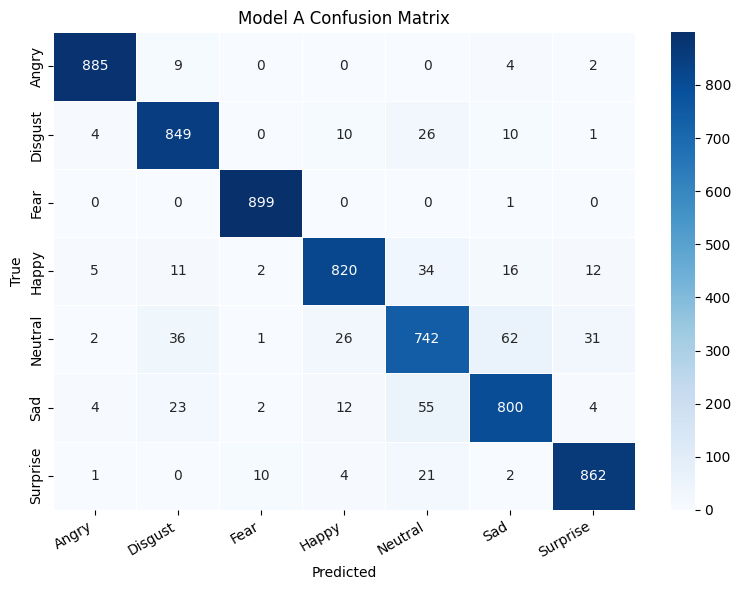

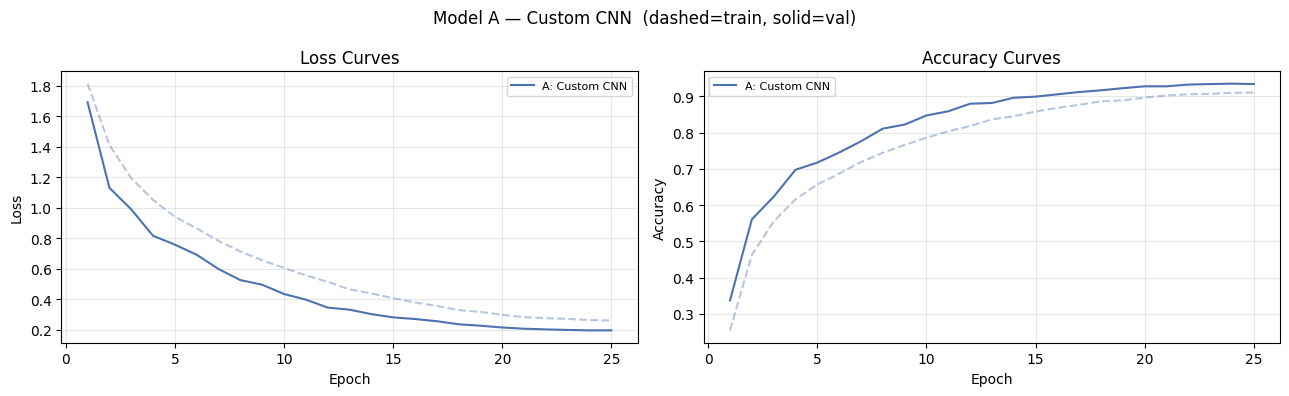


► Baseline: 92.97% accuracy


In [11]:
# CELL 11 — Train Model A: Custom CNN
print('MODEL A — Custom CNN (from scratch, balanced data, single-channel)\n')
modelA    = CustomCNN().to(device)
hist_A,_  = train_model(modelA, nn.CrossEntropyLoss(), 'ModelA_CustomCNN',
                         epochs=NUM_EPOCHS, lr=1e-3,
                         tr_ldr=train_loader1, vl_ldr=val_loader1)
metrics_A = test_metrics(modelA, test_loader1)
print_results(metrics_A, 'Model A — Custom CNN')
plot_cm(metrics_A['cm'], 'Model A Confusion Matrix', 'cm_A')
plot_history({'A: Custom CNN': hist_A}, 'Model A — Custom CNN')
all_results['A: Custom CNN']   = metrics_A
all_histories['A: Custom CNN'] = hist_A
print(f'\n► Baseline: {metrics_A["acc"]*100:.2f}% accuracy')

MODEL B — Pretrained ResNet-50 (transfer learning, 3-channel grayscale)


─────────────────────────────────────────────────────────────────
  Training: ModelB_ResNet50  |  25 epochs  |  lr=0.0001
─────────────────────────────────────────────────────────────────
  Ep |   Tr Loss |  Tr Acc |   Vl Loss |  Vl Acc |        LR
─────────────────────────────────────────────────────────────────
   1 |    1.0980 |  0.5860 |    0.5224 |  0.8177 |  9.96e-05 ✓
   2 |    0.4370 |  0.8461 |    0.2818 |  0.9017 |  9.84e-05 ✓
   3 |    0.2583 |  0.9093 |    0.1827 |  0.9353 |  9.65e-05 ✓
   4 |    0.1720 |  0.9401 |    0.1459 |  0.9505 |  9.39e-05 ✓
   5 |    0.1295 |  0.9544 |    0.1269 |  0.9599 |  9.05e-05 ✓
   6 |    0.0943 |  0.9677 |    0.1126 |  0.9674 |  8.66e-05 ✓
   7 |    0.0801 |  0.9727 |    0.1129 |  0.9679 |  8.21e-05 ✓
   8 |    0.0634 |  0.9779 |    0.0955 |  0.9712 |  7.70e-05 ✓
   9 |    0.0538 |  0.9825 |    0.1018 |  0.9731 |  7.16e-05 ✓
  10 |    0.0416 |  0.9864 |    0.0934 |  0.

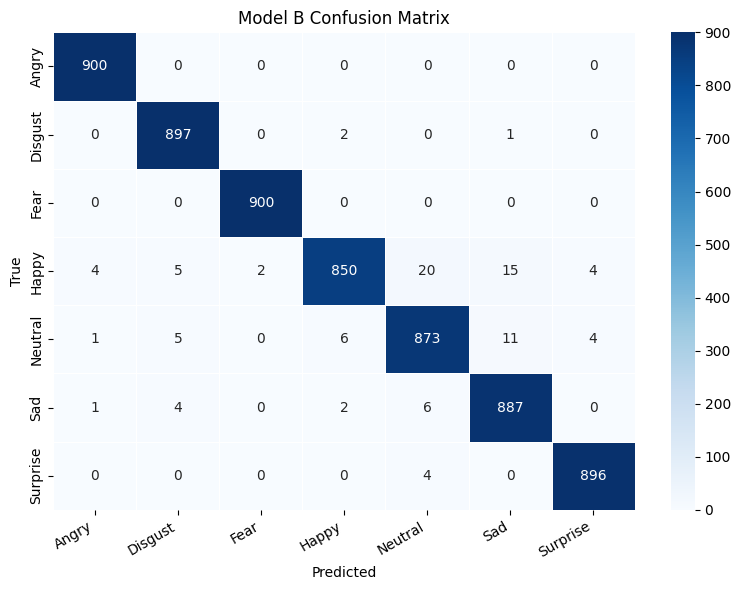

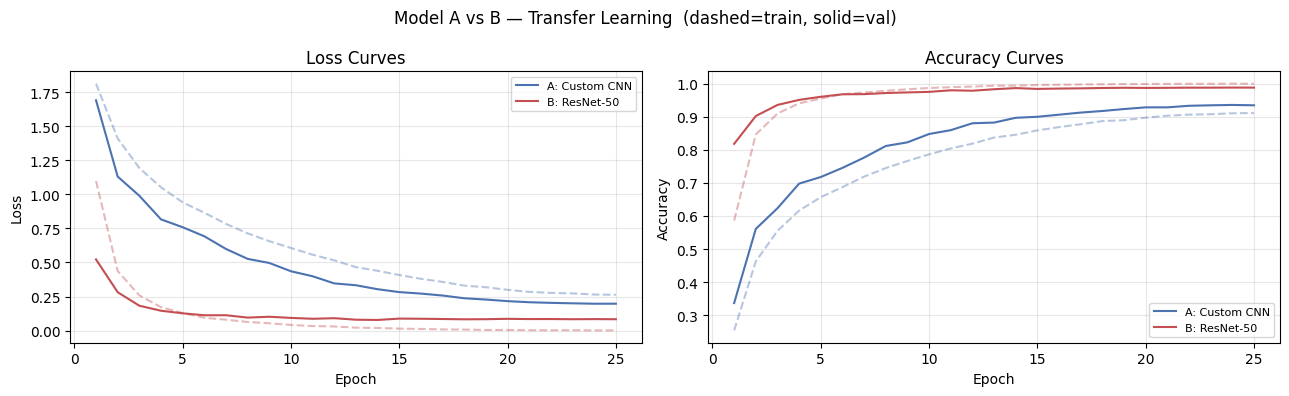


► Transfer learning gain: +5.49% accuracy


In [12]:
# CELL 12 — Train Model B: Pretrained ResNet-50
print('MODEL B — Pretrained ResNet-50 (transfer learning, 3-channel grayscale)\n')
modelB    = ResNet50_Transfer().to(device)
hist_B,_  = train_model(modelB, nn.CrossEntropyLoss(), 'ModelB_ResNet50')
metrics_B = test_metrics(modelB, test_loader3)
print_results(metrics_B, 'Model B — ResNet-50')
plot_cm(metrics_B['cm'], 'Model B Confusion Matrix', 'cm_B')
plot_history({'A: Custom CNN': hist_A, 'B: ResNet-50': hist_B},
             'Model A vs B — Transfer Learning')
all_results['B: ResNet-50']    = metrics_B
all_histories['B: ResNet-50']  = hist_B
print(f'\n► Transfer learning gain: {(metrics_B["acc"]-metrics_A["acc"])*100:+.2f}% accuracy')

In [ ]:
# CELL 13 — Train Model C: ResNet-50 + CBAM
print('MODEL C — ResNet-50 + CBAM Attention (our modification)\n')
modelC    = ResNet50_CBAM().to(device)
hist_C,_  = train_model(modelC, nn.CrossEntropyLoss(), 'ModelC_CBAM')
metrics_C = test_metrics(modelC, test_loader3)
print_results(metrics_C, 'Model C — ResNet-50 + CBAM')
plot_cm(metrics_C['cm'], 'Model C Confusion Matrix', 'cm_C')
plot_history({'B: ResNet-50': hist_B, 'C: +CBAM': hist_C},
             'Model B vs C — CBAM Effect')
all_results['C: ResNet-50+CBAM']   = metrics_C
all_histories['C: +CBAM']          = hist_C
print(f'\n► CBAM gain: {(metrics_C["acc"]-metrics_B["acc"])*100:+.2f}% accuracy')

MODEL C — ResNet-50 + CBAM Attention (our modification)


─────────────────────────────────────────────────────────────────
  Training: ModelC_CBAM  |  25 epochs  |  lr=0.0001
─────────────────────────────────────────────────────────────────
  Ep |   Tr Loss |  Tr Acc |   Vl Loss |  Vl Acc |        LR
─────────────────────────────────────────────────────────────────
   1 |    1.3059 |  0.5030 |    0.7199 |  0.7383 |  9.96e-05 ✓
   2 |    0.6026 |  0.7852 |    0.3990 |  0.8595 |  9.84e-05 ✓
   3 |    0.3573 |  0.8746 |    0.2469 |  0.9101 |  9.65e-05 ✓
   4 |    0.2385 |  0.9172 |    0.2109 |  0.9292 |  9.39e-05 ✓
   5 |    0.1748 |  0.9403 |    0.1680 |  0.9438 |  9.05e-05 ✓
   6 |    0.1313 |  0.9550 |    0.1372 |  0.9570 |  8.66e-05 ✓
   7 |    0.1027 |  0.9651 |    0.1188 |  0.9623 |  8.21e-05 ✓
   8 |    0.0876 |  0.9703 |    0.1056 |  0.9668 |  7.70e-05 ✓
   9 |    0.0692 |  0.9769 |    0.1198 |  0.9680 |  7.16e-05 ✓
  10 |    0.0588 |  0.9811 |    0.1039 |  0.9717 |  6.58e-05 ✓
 

In [ ]:
# CELL 14 — Train Model D: ResNet-50 + CBAM + Focal Loss (full method)
print('MODEL D — ResNet-50 + CBAM + Focal Loss (full proposed method)\n')
modelD    = ResNet50_CBAM().to(device)
hist_D,_  = train_model(modelD, FocalLoss(gamma=2.0), 'ModelD_CBAM_Focal')
metrics_D = test_metrics(modelD, test_loader3)
print_results(metrics_D, 'Model D — ResNet-50 + CBAM + Focal Loss (Ours)')
plot_cm(metrics_D['cm'], 'Model D Confusion Matrix — Full Method', 'cm_D')
plot_history({'A: Custom CNN': hist_A,'B: ResNet-50': hist_B,
              'C: +CBAM': hist_C,     'D: +FocalLoss': hist_D},
             'All Models — Progressive Improvement')
all_results['D: ResNet-50+CBAM+FL (Ours)'] = metrics_D
all_histories['D: +FocalLoss']             = hist_D
print(f'\n► Focal Loss gain: {(metrics_D["acc"]-metrics_C["acc"])*100:+.2f}% accuracy')
print(f'► Total gain A→D : {(metrics_D["acc"]-metrics_A["acc"])*100:+.2f}% accuracy')

---
## Section 3 — Analysis

In [ ]:
# CELL 15 — Ablation table
print('='*70); print('  ABLATION STUDY — Balanced RAF-DB Test Set'); print('='*70)
print(f'  {"Model":<38} {"Acc":>7}  {"MacroF1":>8}  {"Recall":>7}')
print('─'*70)
for name,m in all_results.items():
    mk='  ◄ OURS' if 'Ours' in name else ''
    print(f'  {name:<38} {m["acc"]:>7.4f}  {m["macro_f1"]:>8.4f}  {m["rec"]:>7.4f}{mk}')
print('='*70)

fig,ax=plt.subplots(figsize=(12,5))
x,w=np.arange(NUM_CLASSES),0.2
cols=['#4C72B0','#C44E52','#55A868','#DD8452']
for i,(lbl,col) in enumerate(zip(all_results.keys(),cols)):
    ax.bar(x+i*w,all_results[lbl]['pca'],w,label=lbl.split(':')[0],color=col)
ax.set_xticks(x+1.5*w); ax.set_xticklabels(CLASSES,rotation=15,ha='right')
ax.set_ylabel('Per-class Accuracy'); ax.set_title('Ablation — Per-class Accuracy')
ax.legend(); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/ablation_perclass.png',dpi=150); plt.show()

In [ ]:
# CELL 16 — Hyperparameter sweep: gamma
print('Focal Loss gamma sweep: {0.5, 1.0, 2.0, 3.0, 5.0} — 15 epochs each\n')
gamma_vals=[0.5,1.0,2.0,3.0,5.0]; gamma_res={}
for g in gamma_vals:
    gn=f'sweep_g{str(g).replace(".","p")}'
    m=ResNet50_CBAM().to(device)
    train_model(m,FocalLoss(g),gn,epochs=15,lr=LR)
    met=test_metrics(m,test_loader3); gamma_res[g]=met
    print(f'  γ={g}  Acc={met["acc"]:.4f}  MacroF1={met["macro_f1"]:.4f}')
fig,(a1,a2)=plt.subplots(1,2,figsize=(11,4))
gs=list(gamma_res.keys())
a1.plot(gs,[gamma_res[g]['acc'] for g in gs],'o-',lw=2,ms=8,color='#4C72B0')
a2.plot(gs,[gamma_res[g]['macro_f1'] for g in gs],'o-',lw=2,ms=8,color='#C44E52')
for ax,yl,tl in [(a1,'Accuracy','Accuracy vs γ'),(a2,'Macro F1','Macro F1 vs γ')]:
    ax.axvline(2.0,ls='--',color='gray',alpha=0.7,label='γ=2 chosen')
    ax.set_xlabel('γ'); ax.set_ylabel(yl); ax.set_title(tl); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Hyperparameter Sweep — Focal Loss γ'); plt.tight_layout()
plt.savefig(f'{OUT_DIR}/gamma_sweep.png',dpi=150); plt.show()
best_g=max(gamma_res,key=lambda g:gamma_res[g]['macro_f1'])
print(f'Best γ by Macro F1: {best_g}')

In [ ]:
# CELL 17 — Grad-CAM (Model D)
c=torch.load(os.path.join(CKPT_DIR,'ModelD_CBAM_Focal.pt'),map_location=device)
modelD.load_state_dict(c['model_state_dict']); modelD.eval()
_acts,_grads={},{}
hf=modelD.layer4.register_forward_hook(lambda m,i,o:_acts.update({'f':o.detach()}))
hb=modelD.layer4.register_full_backward_hook(lambda m,gi,go:_grads.update({'f':go[0].detach()}))

def gradcam(img_t, lbl):
    t=img_t.unsqueeze(0).to(device).requires_grad_(True)
    modelD.zero_grad(); logits=modelD(t); pred=logits.argmax(1).item()
    logits[0,lbl].backward()
    w=_grads['f'].mean([2,3],keepdim=True)
    cam=F.relu((w*_acts['f']).sum(1,keepdim=True))
    cam=F.interpolate(cam,(75,75),mode='bilinear',align_corners=False).squeeze().cpu().numpy()
    cam=(cam-cam.min())/(cam.max()-cam.min()+1e-8); return cam,pred

fig,axes=plt.subplots(3,NUM_CLASSES,figsize=(16,7))
shown=[False]*NUM_CLASSES
for img,lbl in test_loader3.dataset:
    if shown[lbl]: continue
    cam,pred=gradcam(img,lbl)
    orig=torch.clamp(img*0.5+0.5,0,1).permute(1,2,0).numpy()
    axes[0,lbl].imshow(orig[:,:,0],cmap='gray'); axes[0,lbl].axis('off')
    axes[0,lbl].set_title(CLASSES[lbl],fontsize=8,fontweight='bold')
    axes[1,lbl].imshow(orig[:,:,0],cmap='gray')
    axes[1,lbl].imshow(cam,cmap='jet',alpha=0.5); axes[1,lbl].axis('off')
    axes[1,lbl].set_title(f'Pred:{CLASSES[pred]}',fontsize=8,color='green' if pred==lbl else 'red')
    axes[2,lbl].imshow(cam,cmap='jet'); axes[2,lbl].axis('off')
    axes[2,lbl].set_title('CAM',fontsize=8)
    shown[lbl]=True
    if all(shown): break
for ax,lb in zip(axes[:,0],['Original','Overlay','CAM']): ax.set_ylabel(lb,fontsize=9)
plt.suptitle('Grad-CAM — Model D attends to eyes, mouth, brow',fontsize=10)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/gradcam.png',dpi=150); plt.show()
hf.remove(); hb.remove(); print('Grad-CAM saved ✓')

In [ ]:
# CELL 18 — Qualitative: correct & incorrect predictions
modelD.eval()
fig,axes=plt.subplots(2,NUM_CLASSES,figsize=(16,5))
cor=[False]*NUM_CLASSES; wrg=[False]*NUM_CLASSES
for i in random.sample(range(len(test_loader3.dataset)),min(1000,len(test_loader3.dataset))):
    img,lbl=test_loader3.dataset[i]
    with torch.inference_mode(): pred=modelD(img.unsqueeze(0).to(device)).argmax(1).item()
    orig=torch.clamp(img*0.5+0.5,0,1)[0].numpy()
    if pred==lbl and not cor[lbl]:
        axes[0,lbl].imshow(orig,cmap='gray'); axes[0,lbl].axis('off')
        axes[0,lbl].set_title(f'✓ {CLASSES[lbl]}',fontsize=8,color='green'); cor[lbl]=True
    elif pred!=lbl and not wrg[lbl]:
        axes[1,lbl].imshow(orig,cmap='gray'); axes[1,lbl].axis('off')
        axes[1,lbl].set_title(f'✗ True:{CLASSES[lbl]}\nPred:{CLASSES[pred]}',fontsize=7,color='red'); wrg[lbl]=True
    if all(cor) and all(wrg): break
axes[0,0].set_ylabel('Correct ✓',fontsize=10,color='green')
axes[1,0].set_ylabel('Incorrect ✗',fontsize=10,color='red')
plt.suptitle('Qualitative Results — Model D')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/qualitative.png',dpi=150); plt.show()

In [ ]:
# CELL 19 — SOTA comparison
print('='*66); print('  STATE-OF-THE-ART COMPARISON — RAF-DB'); print('='*66)
print(f'  {"Method":<44} {"Acc":>7}  {"F1":>8}')
print('─'*66)
sota=[('Custom CNN — ours (A)',metrics_A['acc'],metrics_A['macro_f1']),
      ('ResNet-50 — ours (B)',metrics_B['acc'],metrics_B['macro_f1']),
      ('SE-ResNet-18 [Li 2019]',0.867,None),
      ('ResNet-50+CBAM — ours (C)',metrics_C['acc'],metrics_C['macro_f1']),
      ('FT-CSAT [Zhou 2023]',0.8861,None),
      ('ResNet-50+CBAM+FL — ours (D)',metrics_D['acc'],metrics_D['macro_f1']),
      ('ResNet50+CBAM [Springer 2024]',0.9186,None),
      ('TriCAFFNet [PMC 2024]',0.9217,None)]
for m,acc,f1 in sota:
    f1s=f'{f1:.4f}' if f1 else '   —   '
    mk='  ◄' if 'ours' in m else ''
    print(f'  {m:<44} {acc:.4f}  {f1s:>8}{mk}')
print('='*66)

In [ ]:
# CELL 20 — APPENDIX: Gradio app (all 4 models)
import gradio as gr

def load_ckpt(Cls, name, **kw):
    m=Cls(**kw).to(device)
    c=torch.load(os.path.join(CKPT_DIR,f'{name}.pt'),map_location=device)
    m.load_state_dict(c['model_state_dict']); m.eval(); return m

app_models=[
    ('A: Custom CNN',               load_ckpt(CustomCNN,'ModelA_CustomCNN'),        '1ch'),
    ('B: ResNet-50',                load_ckpt(ResNet50_Transfer,'ModelB_ResNet50'), '3ch'),
    ('C: ResNet-50 + CBAM',         load_ckpt(ResNet50_CBAM,'ModelC_CBAM'),         '3ch'),
    ('D: CBAM + Focal Loss (Best)', load_ckpt(ResNet50_CBAM,'ModelD_CBAM_Focal'),   '3ch'),
]

tf1=v2.Compose([v2.Grayscale(1),v2.Resize((75,75)),v2.ToImage(),v2.ToDtype(torch.float32,scale=True),v2.Normalize([0.5],[0.5])])
tf3=v2.Compose([v2.Grayscale(3),v2.Resize((75,75)),v2.ToImage(),v2.ToDtype(torch.float32,scale=True),v2.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])])

def predict_all(image):
    if image is None: return ({},{},{},{})
    out=[]
    with torch.inference_mode():
        for _,m,ch in app_models:
            t=(tf1 if ch=='1ch' else tf3)(image).unsqueeze(0).to(device)
            p=torch.softmax(m(t),1).squeeze().cpu().numpy()
            out.append({CLASSES[i]:float(p[i]) for i in range(NUM_CLASSES)})
    return tuple(out)

with gr.Blocks(title='RAF-DB FER') as demo:
    gr.Markdown('# Facial Expression Recognition\n**6G7V0024 Deep Learning**\n\nUpload or webcam capture — all 4 models predict simultaneously.')
    with gr.Row():
        with gr.Column(scale=1):
            img_in=gr.Image(sources=['upload','webcam'],type='pil',label='Input Face')
            btn=gr.Button('Classify',variant='primary')
        with gr.Column(scale=3):
            with gr.Row():
                oA=gr.Label(num_top_classes=7,label='A: Custom CNN (baseline)')
                oB=gr.Label(num_top_classes=7,label='B: ResNet-50 (transfer)')
            with gr.Row():
                oC=gr.Label(num_top_classes=7,label='C: ResNet-50 + CBAM')
                oD=gr.Label(num_top_classes=7,label='D: CBAM + Focal Loss ← BEST')
    outs=[oA,oB,oC,oD]
    btn.click(predict_all,img_in,outs)
    img_in.change(predict_all,img_in,outs)

demo.launch(share=True,debug=False)
print('Gradio app launched — copy the public URL for your report appendix.')